# 07. Seaborn 기초 - 실습 문제

## 실습 안내
- 총 8개 문제 (총 100점)
- Seaborn 통계 차트 연습
- 박스플롯, 바이올린 플롯, 히트맵, 카운트 플롯 등

## 환경 설정 및 데이터 로드

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# 한글 폰트 설정
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# Seaborn 스타일 설정
sns.set_style('whitegrid')
sns.set_palette('Set2')

# 데이터 로드
production_df = pd.read_csv('../data/05_production.csv', encoding='utf-8-sig')
sensor_df = pd.read_csv('../data/08_sensor_data.csv', encoding='utf-8-sig')

# 날짜 변환
production_df['production_date'] = pd.to_datetime(production_df['production_date'])
sensor_df['measurement_time'] = pd.to_datetime(sensor_df['measurement_time'])

# 불량률 계산
production_df['defect_rate'] = (
    production_df['defect_quantity'] / production_df['actual_quantity'] * 100
).round(2)

print("데이터 로드 완료!")

데이터 로드 완료!


---
## 문제 1: 교대조별 불량률 박스플롯 (10점)

**요구사항**:
1. 교대조별 불량률 박스플롯 생성
2. 색상 팔레트: 'Set2'
3. 선 굵기: 2
4. 제목: '교대조별 불량률 분포'
5. Figure 크기: (10, 6)



In [2]:
from koreanize_matplotlib import koreanize
koreanize()

In [3]:
# 여기에 코드 작성
production_df.groupby('shift')['defect_rate'].mean()

shift
DAY       8.815769
NIGHT    11.629615
Name: defect_rate, dtype: float64

Text(0.5, 1.0, '교대조별 불량률 분포')

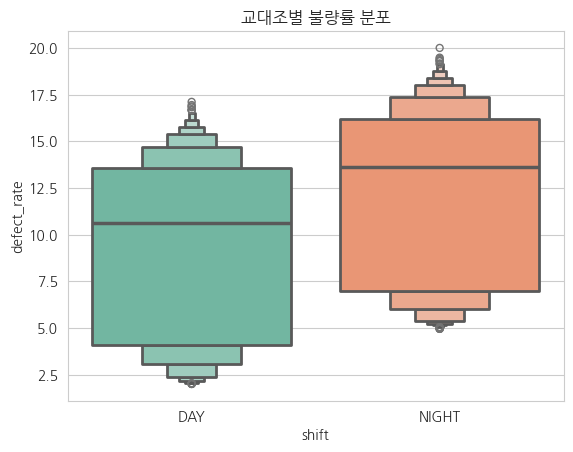

In [5]:
sns.boxenplot(data=production_df,x='shift',y='defect_rate',palette='Set2',linewidth=2)
plt.title('교대조별 불량률 분포')

---
## 문제 2: 제품-교대조별 생산량 바이올린 플롯 (15점)

**요구사항**:
1. 제품별로 교대조 생산량을 바이올린 플롯으로 비교
2. 색상 팔레트: 'Set2'
3. 제목: '제품-교대조별 생산량 분포'
4. 범례 추가
5. Figure 크기: (12, 6)



<Axes: xlabel='product_code', ylabel='actual_quantity'>

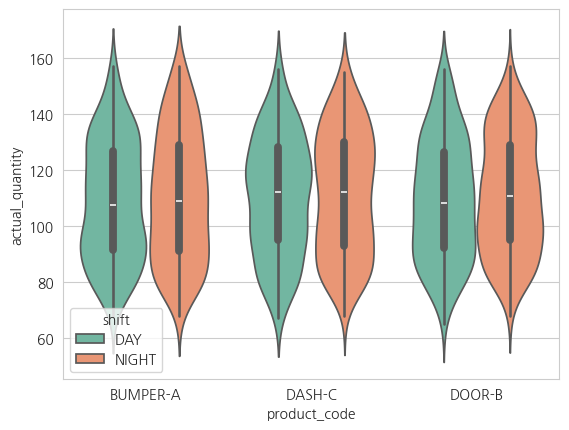

In [6]:
sns.violinplot(data= production_df, x= 'product_code', y= 'actual_quantity', hue='shift')


---
## 문제 3: 센서 데이터 상관관계 히트맵 (15점)

**요구사항**:
1. 센서 데이터의 상관관계 계산 (temperature, pressure, vibration, current)
2. 히트맵 생성:
   - annot=True, fmt='.3f'
   - cmap='coolwarm'
   - center=0
   - square=True
   - linewidths=1
3. 제목: '센서 데이터 상관관계 매트릭스'
4. Figure 크기: (8, 6)



In [9]:
# 여기에 코드 작성
sensor_corr=sensor_df[['temperature','pressure','vibration','current']].corr()

In [10]:
sensor_corr

,temperature,pressure,vibration,current
temperature,1.000000,0.450458,0.104163,-0.099645
pressure,0.450458,1.000000,0.837068,0.840483
vibration,0.104163,0.837068,1.000000,0.872423
current,-0.099645,0.840483,0.872423,1.000000


<function matplotlib.pyplot.show(close=None, block=None)>

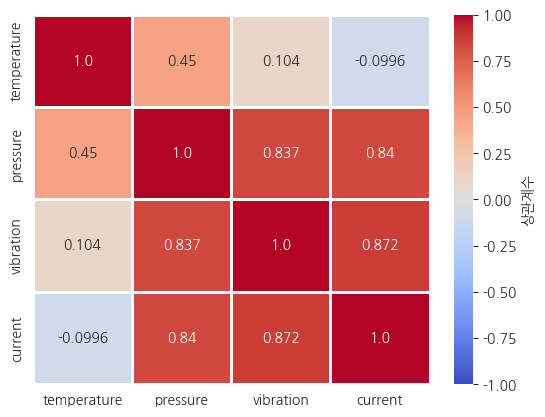

In [18]:
sns.heatmap(data=sensor_corr, annot = True, fmt='.3',cmap='coolwarm', vmin=-1,vmax=1, linewidths=1,cbar_kws={'label':'상관계수'})
plt.show

---
## 문제 4: 제품-교대조 평균 사이클 타임 히트맵 (15점)

**요구사항**:
1. 제품-교대조별 평균 사이클 타임 피벗 테이블 생성
2. 히트맵 생성:
   - annot=True, fmt='.1f'
   - cmap='YlGnBu'
   - linewidths=1
   - cbar_kws={"label": "평균 사이클 타임 (초)"}
3. 제목: '제품-교대조별 평균 사이클 타임'
4. Figure 크기: (8, 6)



In [19]:
# 여기에 코드 작성
production_df


,production_id,equipment_id,product_code,production_date,start_time,end_time,target_quantity,actual_quantity,good_quantity,defect_quantity,cycle_time,work_order_no,lot_no,operator_id,shift,created_at,updated_at,defect_rate
0,1,INJ-001,BUMPER-A,2024-01-01,2024-01-01 08:14:00,2024-01-01 09:53:32,97,81,77,4,73.73,WO202401019935,LOT2024010100101,OP003,DAY,2026-01-30 00:42:48,2026-01-30 00:42:48,4.94
1,2,INJ-001,BUMPER-A,2024-01-01,2024-01-01 21:02:00,2024-01-01 22:33:43,83,78,72,6,70.56,WO202401012535,LOT2024010100110,OP006,NIGHT,2026-01-30 00:42:48,2026-01-30 00:42:48,7.69
2,3,INJ-002,BUMPER-A,2024-01-01,2024-01-01 10:12:00,2024-01-01 13:16:28,149,135,132,3,81.99,WO202401018359,LOT2024010100201,OP001,DAY,2026-01-30 00:42:48,2026-01-30 00:42:48,2.22
3,4,INJ-002,DASH-C,2024-01-01,2024-01-01 12:48:00,2024-01-01 15:16:31,100,92,90,2,96.87,WO202401016574,LOT2024010100202,OP003,DAY,2026-01-30 00:42:48,2026-01-30 00:42:48,2.17
4,5,INJ-002,DOOR-B,2024-01-01,2024-01-01 20:48:00,2024-01-01 23:12:13,123,129,122,7,67.08,WO202401012674,LOT2024010100210,OP004,NIGHT,2026-01-30 00:42:48,2026-01-30 00:42:48,5.43
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1867,1868,PRESS-002,BUMPER-A,2024-03-31,2024-03-31 20:19:00,2024-03-31 23:25:19,150,144,119,25,77.63,WO202403317101,LOT2024033100210,OP006,NIGHT,2026-01-30 00:42:48,2026-01-30 00:42:48,17.36
1868,1869,PRESS-002,DASH-C,2024-03-31,2024-04-01 00:15:00,2024-04-01 02:59:58,136,130,109,21,76.15,WO202403318434,LOT2024033100211,OP004,NIGHT,2026-01-30 00:42:48,2026-01-30 00:42:48,16.15
1869,1870,PRESS-002,BUMPER-A,2024-03-31,2024-04-01 05:53:00,2024-04-01 07:26:15,84,80,66,14,69.95,WO202403317294,LOT2024033100212,OP004,NIGHT,2026-01-30 00:42:48,2026-01-30 00:42:48,17.50
1870,1871,ASM-001,BUMPER-A,2024-03-31,2024-03-31 10:24:00,2024-03-31 13:25:41,143,121,101,20,90.10,WO202403317268,LOT2024033100101,OP003,DAY,2026-01-30 00:42:48,2026-01-30 00:42:48,16.53


In [22]:
cycle_df=pd.pivot_table(production_df,index='product_code',columns='shift',values='cycle_time',aggfunc='mean')

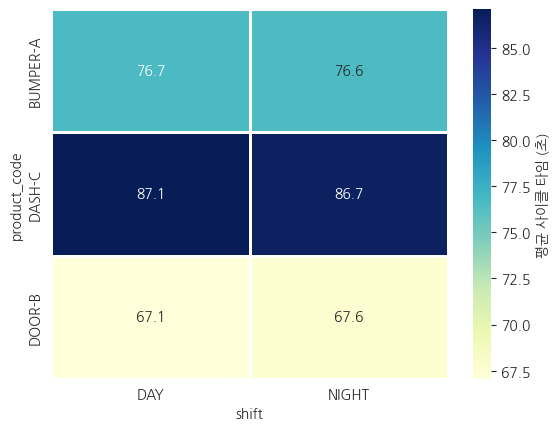

<Figure size 800x600 with 0 Axes>

<Figure size 800x600 with 0 Axes>

In [26]:
sns.heatmap(cycle_df,annot=True, fmt='.1f',cmap='YlGnBu',linewidths=1,cbar_kws={"label": "평균 사이클 타임 (초)"} )
plt.show()
plt.figure(figsize=(8,6))

---
## 문제 5: 제품별 생산 건수 카운트 플롯 (10점)

**요구사항**:
1. 제품별 생산 건수 카운트 플롯
2. 교대조별로 색상 구분 (hue='shift')
3. 색상 팔레트: 'Set2'
4. 제목: '제품-교대조별 생산 건수'
5. 범례 추가
6. Figure 크기: (10, 6)



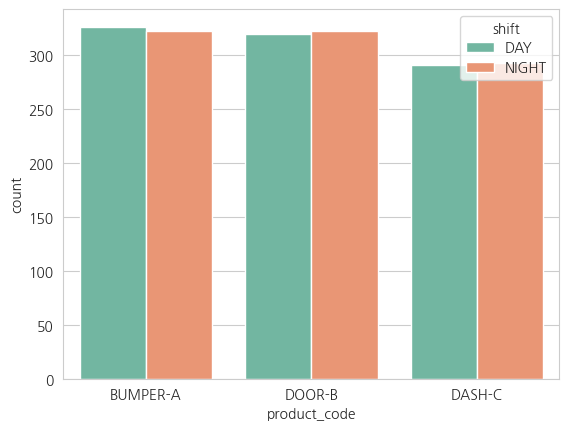

In [34]:
# 여기에 코드 작성
myorder=production_df['product_code'].value_counts().index
sns.countplot(data=production_df,x='product_code',hue='shift', order= myorder)
plt.show()

Index(['BUMPER-A', 'DOOR-B', 'DASH-C'], dtype='object', name='product_code')

In [ ]:
pd.crosstab()

ValueError: If using all scalar values, you must pass an index

---
## 문제 6: 제품별 평균 불량률 바 플롯 (10점)

**요구사항**:
1. 제품별 평균 불량률 바 플롯
2. 오차 막대: 표준편차 (ci='sd')
3. 색상 팔레트: 'Set2'
4. 제목: '제품별 평균 불량률 (±표준편차)'
5. Figure 크기: (10, 6)



In [35]:
# 여기에 코드 작성
production_df.groupby('product_code')['defect_rate'].mean()

product_code
BUMPER-A    10.376590
DASH-C      10.121681
DOOR-B      10.158986
Name: defect_rate, dtype: float64

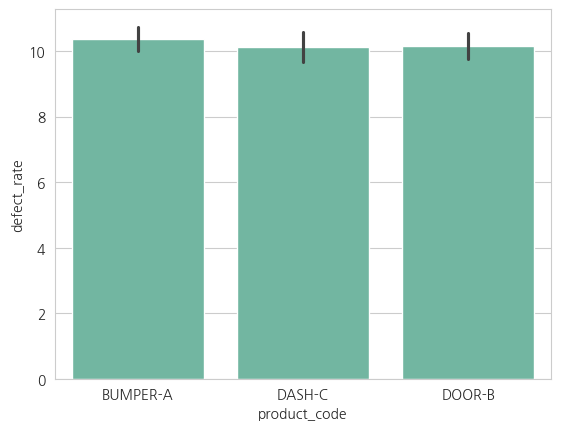

In [38]:
sns.barplot(data=production_df, x='product_code',y='defect_rate')
plt.show()

---
## 문제 7: 센서 데이터 페어플롯 (15점)

**요구사항**:
1. 센서 데이터 500개 샘플링 (random_state=42)
2. temperature, pressure, vibration, current 4개 변수 페어플롯
3. diag_kind='kde'
4. 전체 제목: '센서 데이터 페어플롯 (샘플)'
   - `plt.suptitle(..., y=1.02)`



In [39]:
# 여기에 코드 작성
sensor_df[['temperature', 'pressure', 'vibration', 'current']].corr()

,temperature,pressure,vibration,current
temperature,1.000000,0.450458,0.104163,-0.099645
pressure,0.450458,1.000000,0.837068,0.840483
vibration,0.104163,0.837068,1.000000,0.872423
current,-0.099645,0.840483,0.872423,1.000000


In [40]:
sensor_pair=sensor_df[['temperature', 'pressure', 'vibration', 'current']]

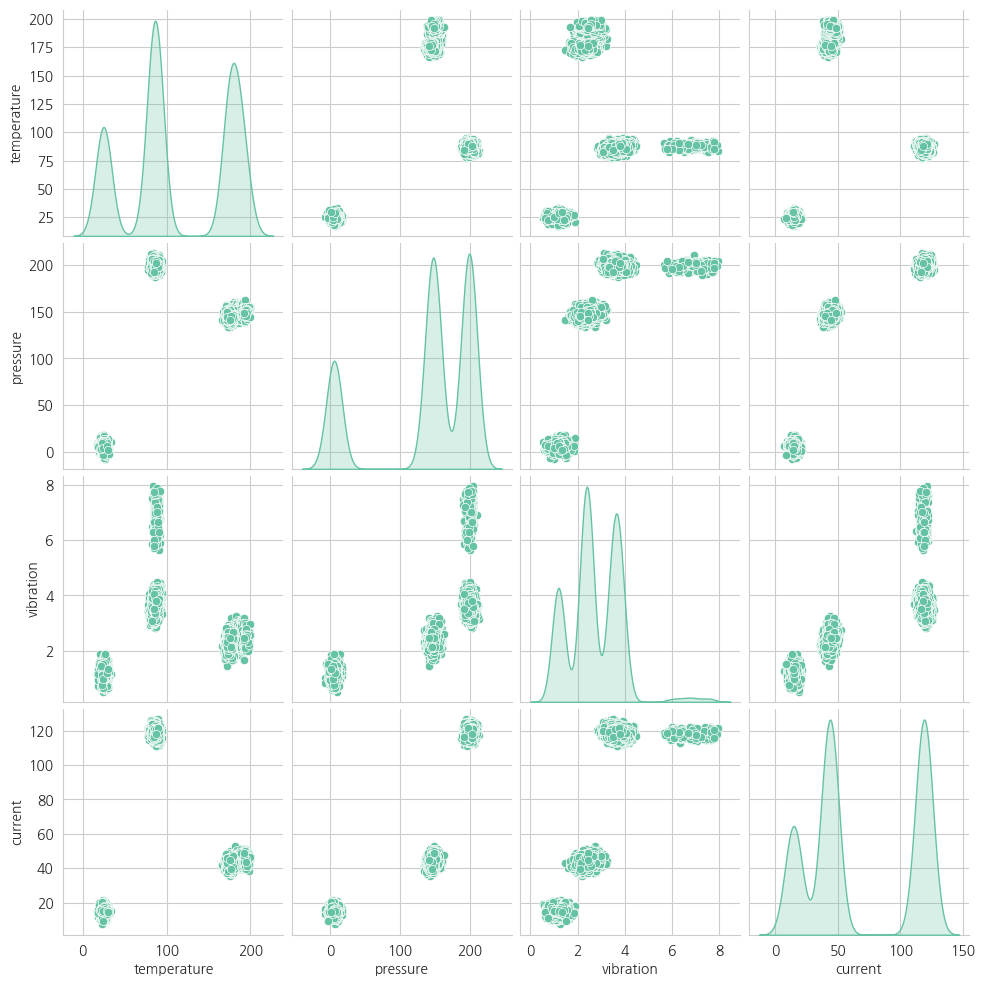

In [42]:
sns.pairplot(sensor_pair,diag_kind='kde')

---
## 문제 8: 복합 플롯 - 박스플롯 + 스트립플롯 (20점)

**요구사항**:
제품별 사이클 타임 분포를 박스플롯과 스트립플롯으로 동시 표시

1. 먼저 박스플롯 그리기:
   - x='product_code', y='cycle_time'
   - palette='Set2', width=0.5

2. 그 위에 스트립플롯 오버레이:
   - x='product_code', y='cycle_time'
   - color='black', alpha=0.2, size=2

3. 제목: '제품별 사이클 타임 분포 (박스플롯 + 데이터 포인트)'
4. Figure 크기: (10, 6)

**힌트**: 같은 axes에 두 개의 플롯을 순차적으로 그리기

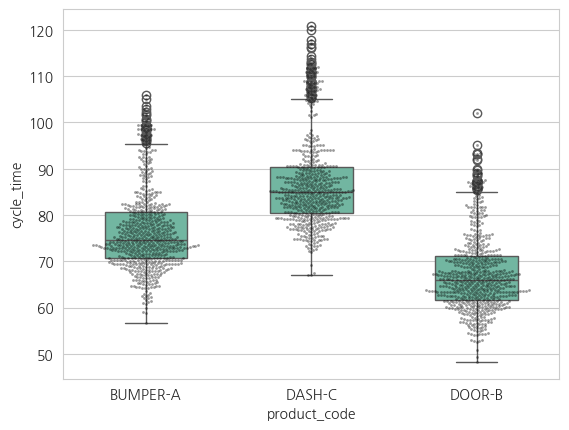

In [51]:
# 여기에 코드 작성
sns.boxplot(data= production_df, x= 'product_code', y= 'cycle_time',width=0.5)
sns.swarmplot(data= production_df, x= 'product_code', y= 'cycle_time',color='black',size=2,alpha=0.4)

plt.show()

---
## 수고하셨습니다!

### 학습 체크리스트
- [ ] 박스플롯으로 분포 비교
- [ ] 바이올린 플롯으로 밀도 표시
- [ ] 히트맵으로 상관관계 분석
- [ ] 히트맵으로 피벗 테이블 시각화
- [ ] 카운트 플롯으로 빈도 분석
- [ ] 바 플롯으로 평균과 오차 표시
- [ ] 페어플롯으로 변수 간 관계 파악
- [ ] 복합 플롯으로 다층 정보 표시
